# The ANI-2x dataset: seven elements (S, F, Cl) and the `ani-2x` preset

The **ANI-2x dataset** (Devereux *et al.*, *J. Chem. Theory Comput.* **16**,
4192, 2020) is the training set behind the **ANI-2x** potential, the
seven-element extension of ANI. Where ANI-1/ANI-1x/ANI-1ccx cover only
H, C, N, O, ANI-2x adds **S, F, and Cl**, the elements that (with the original
four) make up ~90% of drug-like molecules. It was built by the same active
learning procedure as ANI-1x, giving ~9.6 million wB97X/6-31G(d) conformations
with **energies and forces**.

Same one-line hub as every other dataset. The first call downloads the
~3.7 GB wB97X/6-31G(d) archive from Zenodo (record 10108942), cached and
MD5-verified under `datasets/ani2x/`:

```python
from xnns.common.data import load_dataset
data = load_dataset("ani2x", n_atoms=[5, 6, 7])   # atom-count groups
```

The ANI-2x HDF5 groups conformations by **total number of atoms** (`"002"`,
`"003"`, ...), and within a group each conformation can be a different molecule
with that atom count. Here we load a capped subset that contains the new
elements, train the `xnns` **`ani-2x` preset** on energies *and* forces, and
look at both parities plus a per-element breakdown. This is the seven-element
companion to `ani1x_dataset.ipynb`.

Run with the **`xnns`** kernel.

## 0. Load a subset of ANI-2x, including S/F/Cl

`n_atoms` picks which atom-count groups to read; `max_conformations` caps each
group so the demo trains in minutes. Energies convert to eV and forces to
eV/A. Note the seven elements and the per-atom `forces`, absent from ANI-1.

In [1]:
import time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

from xnns.common.data import load_dataset

# a handful of atom-count groups, capped per group; wB97X/6-31G* energies+forces
data = load_dataset("ani2x", n_atoms=[5, 6, 7, 8], max_conformations=1500,
                    units="eV")["all"]
print(f"loaded {len(data):,} conformations")

Z_ALL = {1: "H", 6: "C", 7: "N", 8: "O", 16: "S", 9: "F", 17: "Cl"}
counts = {z: 0 for z in Z_ALL}
for s in data:
    for z in s["atomic_numbers"]:
        counts[int(z)] += 1
print("atom counts by element:",
      {Z_ALL[z]: counts[z] for z in Z_ALL})
n_heavy_halogen = sum(any(int(z) in (16, 9, 17) for z in s["atomic_numbers"])
                      for s in data)
print(f"conformations containing S/F/Cl: {n_heavy_halogen:,} / {len(data):,}")
print(f"keys per structure: {sorted(data[0])}   # note 'forces'")
print(f"force array shape (atoms, 3): {data[0]['forces'].shape}")

ani2x:   0%|          | 0/4 [00:00<?, ? group/s]

loaded 6,000 conformations
atom counts by element: {'H': 14577, 'C': 8503, 'N': 4226, 'O': 5688, 'S': 2357, 'F': 1909, 'Cl': 1740}
conformations containing S/F/Cl: 2,971 / 6,000
keys per structure: ['atomic_numbers', 'energy', 'forces', 'pos']   # note 'forces'
force array shape (atoms, 3): (5, 3)


## 1. Self atomic energies as model references + train/test split

As for the other ANI presets, fit per-element self atomic energies by least
squares over the seven elements and hand them to the model as `atomic_energies`
(constant per atom, so they leave the forces untouched). The S and Cl values
are large and negative because of their extra core electrons. Then a random
90/10 train/test split.

In [2]:
SPECIES = [1, 6, 7, 8, 16, 9, 17]        # H, C, N, O, S, F, Cl (torchani order)
counts = np.array([[np.sum(s["atomic_numbers"] == z) for z in SPECIES]
                   for s in data], float)
E = np.array([s["energy"] for s in data])
sae, *_ = np.linalg.lstsq(counts, E, rcond=None)
print("self energies (eV):", {Z_ALL[z]: round(float(e), 1)
                              for z, e in zip(SPECIES, sae)})

rng = np.random.default_rng(0)
idx = rng.permutation(len(data)); cut = int(0.9 * len(data))
train_structs = [data[i] for i in idx[:cut]]
test_structs = [data[i] for i in idx[cut:]]
print(f"train {len(train_structs)}  test {len(test_structs)}")

self energies (eV): {'H': -16.2, 'C': -1036.2, 'N': -1488.9, 'O': -2045.9, 'S': -10834.3, 'F': -2716.1, 'Cl': -12521.8}
train 5400  test 600


## 2. Train the `ani-2x` preset on energies *and* forces

We select the model with the **`preset: ani-2x`** config key, the 1008-length
AEV (5.1/3.5 A cutoffs, shift grids from 0.8 A), the seven-element wider
networks (H `256:192:160`, C `224:192:160`, N/O `192:160:128`,
S/F/Cl `160:128:96`) and `CELU` of `ANI.ani2x()`, and pass the fitted self
energies through `atomic_energies`. The neighbour-list cutoff is 5.1 A (the
ANI-2x radial cutoff).

In [3]:
from torch.utils.data import Subset
from xnns.common.data import AtomicDataset
from xnns.common.config import Config, ModelConfig, DataConfig, OptimConfig
from xnns.common.train import Trainer

CUTOFF = 5.1                      # ANI-2x radial cutoff (>= angular 3.5)
EPOCHS, BS, LR = 120, 64, 1e-3
train_ds = AtomicDataset(train_structs, CUTOFF)
test_ds = AtomicDataset(test_structs, CUTOFF)

cfg = Config(
    model=ModelConfig(name="ani", cutoff=CUTOFF,
                      extra={"preset": "ani-2x", "species": SPECIES,
                             "atomic_energies": sae.tolist()}),
    data=DataConfig(cutoff=CUTOFF, batch_size=BS),   # val_fraction 0.1 carves val
    optim=OptimConfig(lr=LR, epochs=EPOCHS, energy_weight=1.0,
                      force_weight=10.0, scheduler="plateau"),
    output_dir="runs/ani2x_subset",
)
trainer = Trainer(cfg, train_ds, test_set=test_ds)
print(f"ANI-2x parameters: {sum(p.numel() for p in trainer.module.parameters()):,}"
      f"  device {trainer.device}")

t0 = time.time(); trainer.fit()
print(f"trained {EPOCHS} epochs in {time.time()-t0:.0f}s")

ANI-2x parameters: 1,713,223  device cuda


epoch    0 | train loss 2.1616e+01 | val loss 1.3778e+01


epoch    1 | train loss 1.0254e+01 | val loss 1.0514e+01


epoch    2 | train loss 7.0194e+00 | val loss 1.0726e+01


epoch    3 | train loss 6.2858e+00 | val loss 9.3168e+00


...

epoch  116 | train loss 1.0149e-01 | val loss 4.7879e+00


epoch  117 | train loss 1.0010e-01 | val loss 4.7857e+00


epoch  118 | train loss 9.9645e-02 | val loss 4.7752e+00


epoch  119 | train loss 9.8577e-02 | val loss 4.7781e+00


test loss 1.2325e+00
trained 120 epochs in 674s


## 3. Energy *and* force correlation vs DFT

Because ANI-2x carries forces we check both. There is **no** `torch.no_grad()`
here: forces are `-dE/dx`, so the energy must keep its graph; we detach the
tensors after the model call instead.

energy RMSE: 443.8 meV = 10.234 kcal/mol
force  RMSE: 354.0 meV/A


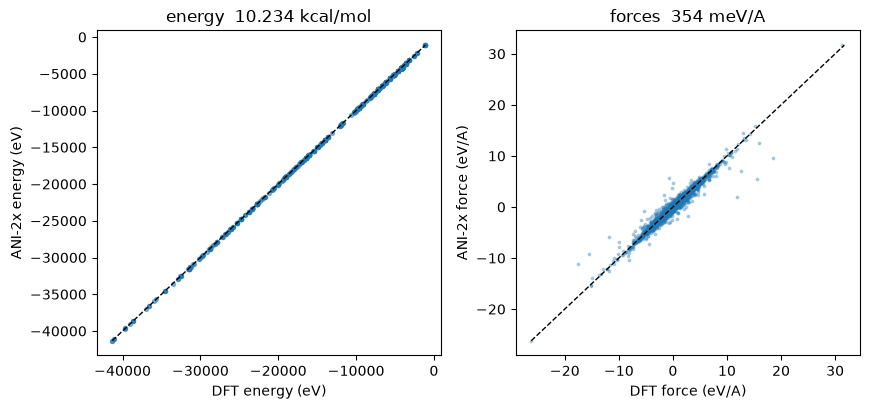

In [4]:
from torch.utils.data import DataLoader
from xnns.common.data import collate

model = trainer.model.eval(); device = trainer.device
EV2KCAL = 23.060541945329334
E_pred, E_ref, F_pred, F_ref = [], [], [], []
for batch in DataLoader(test_ds, batch_size=64, collate_fn=collate):
    batch = batch.to(device)
    out = model(batch)                       # forces need autograd, no no_grad()
    E_pred.append(out["energy"].detach().cpu().numpy())
    F_pred.append(out["forces"].detach().cpu().numpy())
    E_ref.append(batch.energy.cpu().numpy())
    F_ref.append(batch.forces.cpu().numpy())
E_pred, E_ref = np.concatenate(E_pred), np.concatenate(E_ref)
F_pred, F_ref = np.concatenate(F_pred), np.concatenate(F_ref)
e_rmse = np.sqrt(np.mean((E_pred - E_ref) ** 2))
f_rmse = np.sqrt(np.mean((F_pred - F_ref) ** 2))
print(f"energy RMSE: {e_rmse*1e3:.1f} meV = {e_rmse*EV2KCAL:.3f} kcal/mol")
print(f"force  RMSE: {f_rmse*1e3:.1f} meV/A")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.8, 4.2))
a1.scatter(E_ref, E_pred, s=8, alpha=0.5)
lim = [min(E_ref.min(), E_pred.min()), max(E_ref.max(), E_pred.max())]
a1.plot(lim, lim, "k--", lw=1)
a1.set_xlabel("DFT energy (eV)"); a1.set_ylabel("ANI-2x energy (eV)")
a1.set_title(f"energy  {e_rmse*EV2KCAL:.3f} kcal/mol")
fl = [min(F_ref.min(), F_pred.min()), max(F_ref.max(), F_pred.max())]
a2.scatter(F_ref.ravel(), F_pred.ravel(), s=3, alpha=0.3)
a2.plot(fl, fl, "k--", lw=1)
a2.set_xlabel("DFT force (eV/A)"); a2.set_ylabel("ANI-2x force (eV/A)")
a2.set_title(f"forces  {f_rmse*1e3:.0f} meV/A")
fig.tight_layout(); fig.savefig("ani2x_correlation.png", dpi=110); plt.show()

## Summary

`load_dataset("ani2x", ...)` brings the ~9.6 M-conformation, seven-element
ANI-2x training set (**energies and forces** for H/C/N/O/S/F/Cl) into the same
one-line hub as every other `xnns` dataset. Paired with the **`ani-2x` preset**
(`ANI.ani2x()`), this reproduces the ANI-2x model's training setup: the larger
1008-length AEV, the wider per-element networks, and a force-aware loss.

The full ANI family in the hub, side by side:

| | elements | labels | preset |
|---|---|---|---|
| ANI-1 (`ani1`) | H C N O | energies | `ANI.ani1()` |
| ANI-1x (`ani1x`) | H C N O | energies **+ forces** | `ANI.ani1x()` |
| ANI-1ccx (`ani1ccx`) | H C N O | CCSD(T)*/CBS energies | `ANI.ani1ccx()` |
| ANI-2x (`ani2x`) | **+ S F Cl** | energies **+ forces** | `ANI.ani2x()` |

For the **pretrained** ANI-2x weights transplanted from torchani (rather than
trained here), see `examples/fidelity_checks/ani_verification.ipynb` and the
parity tests in `tests/test_ani.py`.